## Finetuning EnergyTSPulse for Energy Anomaly Detection

This notebook demonstrates how to fine-tune **EnergyTSPulse**, a reconstruction-based time-series foundation model pretrained on large-scale energy meter data, for anomaly detection. EnergyTSPulse operates on fixed-length input windows with a `context length of 512`, enabling it to capture long-range temporal dependencies, seasonality, and usage dynamics common in building energy consumption.

During fine-tuning, the model is trained to reconstruct normal energy patterns from 512-length sequences. Anomalies are detected using reconstruction error (optionally combining time- and frequency-domain discrepancies). Windows with high reconstruction error indicate abnormal energy behavior.

The workflow includes:
- Loading pretrained EnergyTSPulse weights  
- Preparing and normalizing building-level time-series data  
- Fine-tuning the model on training data using reconstruction loss  
- Computing anomaly scores from reconstruction error  
- Evaluating detection performance using window-level precision, recall, and F1-score  

This approach adapts pretrained temporal representations to a specific dataset while retaining the general energy dynamics learned during pretraining.


In [1]:

from transformers import AutoConfig
from safetensors.torch import load_file
import os, gc, json, logging
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import KFold
from safetensors.torch import load_file
import matplotlib.pyplot as plt
import seaborn as sns
logging.getLogger("transformers").setLevel(logging.ERROR)
from tsfm_public.models.tspulse import TSPulseForClassification
from tsfm_public.models.tspulse.modeling_tspulse import TSPulseForReconstruction, get_fft


### 📊 Dataset Overview & Exploratory Analysis

we load the energy anomaly detection dataset and perform basic exploratory analysis. We inspect dataset statistics, handle missing values using building-wise median imputation, and visualize overall consumption patterns.

Finally, we plot the time series of a sample building with anomaly points highlighted to gain an intuitive understanding of abnormal energy behavior before model evaluation.

In [2]:
# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
csv_path = "../Dataset/AnomalyDetection/lead_train.csv"
gpu_id   = 0

device = f"cuda:{gpu_id}" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Device selected: {device}")


[INFO] Device selected: cuda:0


In [3]:
# -------------------------------------------------------
# Load Dataset
# -------------------------------------------------------
df = pd.read_csv(csv_path, parse_dates=["timestamp"])
df.sort_values(["building_id", "timestamp"], inplace=True)

print("\n[INFO] Dataset Loaded")
print("Shape:", df.shape)
print("Unique Buildings:", df["building_id"].nunique())

print("\n[INFO] Missing Values:")
print(df.isna().sum())

df.head()


[INFO] Dataset Loaded
Shape: (1749494, 4)
Unique Buildings: 200

[INFO] Missing Values:
building_id           0
timestamp             0
meter_reading    107653
anomaly               0
dtype: int64


,building_id,timestamp,meter_reading,anomaly
0,1,2016-01-01 00:00:00,NaN,0
200,1,2016-01-01 01:00:00,NaN,0
398,1,2016-01-01 02:00:00,NaN,0
597,1,2016-01-01 03:00:00,NaN,0
796,1,2016-01-01 04:00:00,NaN,0


#### Let's Sample one Building from the Dataset 

In [4]:
sample_building = df["building_id"].unique()[64]
sample_df = df[df["building_id"] == sample_building]

In [5]:

# -------------------------------------------------------
# Fill Missing Values
# -------------------------------------------------------
sample_df["meter_reading"] = (
    sample_df["meter_reading"]
      .transform(lambda s: s.fillna(s.median()))
)

print("[INFO] Filled missing meter_reading per building using median.")


[INFO] Filled missing meter_reading per building using median.


/tmp/ipykernel_1213005/2099979673.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df["meter_reading"] = (


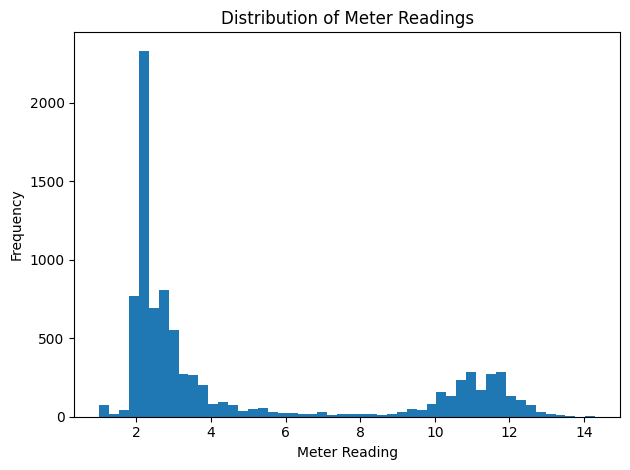

In [6]:


# -------------------------------------------------------
# Global Distribution
# -------------------------------------------------------
plt.figure()
plt.hist(sample_df["meter_reading"], bins=50)
plt.title("Distribution of Meter Readings")
plt.xlabel("Meter Reading")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()




[INFO] Visualizing Building 677


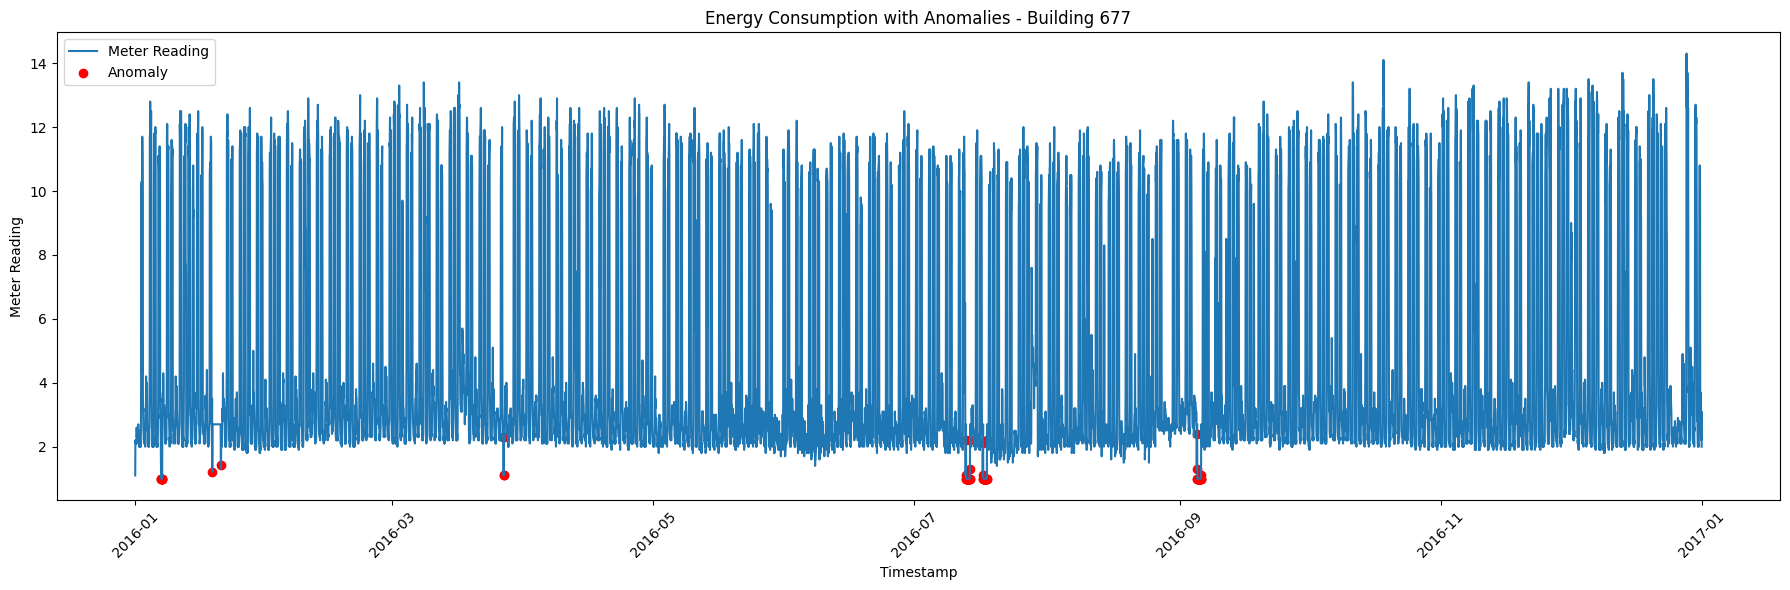

In [7]:

# -------------------------------------------------------
# Sample Building Visualization (Time Series + Anomalies)
# -------------------------------------------------------


print(f"\n[INFO] Visualizing Building {sample_building}")

plt.figure(figsize=(18, 6))

# Full time-series
plt.plot(
    sample_df["timestamp"],
    sample_df["meter_reading"],
    label="Meter Reading"
)

# Overlay anomalies in red
if "anomaly" in sample_df.columns:
    anomalies = sample_df[sample_df["anomaly"] == 1]
    plt.scatter(
        anomalies["timestamp"],
        anomalies["meter_reading"],
        color="red",
        label="Anomaly"
    )

plt.title(f"Energy Consumption with Anomalies - Building {sample_building}")
plt.xlabel("Timestamp")
plt.ylabel("Meter Reading")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Baseline Model for Anomaly detection 

INFO:p-1213005:t-137364085212992:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:p-1213005:t-137364085212992:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


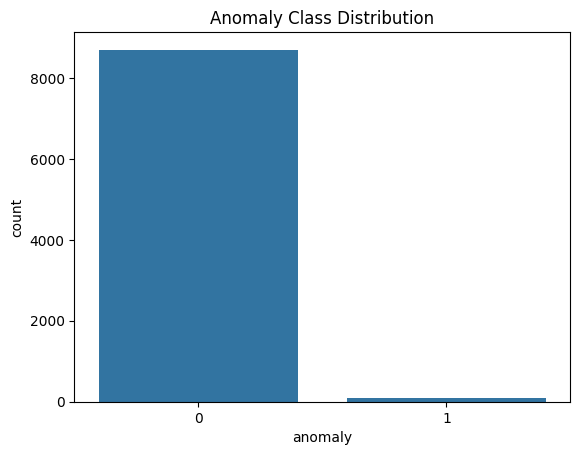

anomaly
0    0.978682
1    0.021318
Name: proportion, dtype: float64


In [8]:
sns.countplot(x=sample_df["anomaly"])
plt.title("Anomaly Class Distribution")
plt.show()

print(df["anomaly"].value_counts(normalize=True))


### Split the dataset into train and test

In [9]:
split_idx = len(sample_df) // 2

train_df = sample_df.iloc[:split_idx].copy()
test_df  = sample_df.iloc[split_idx:].copy()

print("Train range:", train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Test range :", test_df["timestamp"].min(),  "→", test_df["timestamp"].max())


Train range: 2016-01-01 00:00:00 → 2016-07-01 23:00:00
Test range : 2016-07-02 00:00:00 → 2016-12-31 23:00:00


In [10]:
# Train anomaly percentage
train_anom_pct = 100 * train_df["anomaly"].mean()

# Test anomaly percentage
test_anom_pct = 100 * test_df["anomaly"].mean()

print(f"Train anomaly percentage: {train_anom_pct:.2f}%")
print(f"Test anomaly percentage : {test_anom_pct:.2f}%")


Train anomaly percentage: 0.30%
Test anomaly percentage : 1.66%


### Interquartile Range (IQR) for Anomaly Detection

In [11]:
Q1 = train_df["meter_reading"].quantile(0.25)
Q3 = train_df["meter_reading"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)


Lower bound: -4.1000000000000005
Upper bound: 12.700000000000001


In [12]:
# Create a new column for IQR-based anomaly detection
test_df["iqr_pred"] = (
    (test_df["meter_reading"] < lower_bound) |
    (test_df["meter_reading"] > upper_bound)
).astype(int)


### Modified Z Score for Anomaly detection

In [13]:
# Calculate median and MAD for robust statistics
median = train_df["meter_reading"].median()
mad = np.median(np.abs(train_df["meter_reading"] - median))

print("Median:", median)
print("MAD:", mad)


Median: 2.7
MAD: 0.6000000000000001


In [14]:
# Calculate modified Z-scores
mz_scores = 0.6745 * (test_df["meter_reading"] - median) / (mad + 1e-8)

test_df["mz_pred"] = (np.abs(mz_scores) > 3.5).astype(int)


In [15]:
def calc_window_metrics(y_true, y_pred, window_size):
    """
    Computes window-wise anomaly classification metrics.
    A window is anomalous if it contains ANY anomaly.
    """

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    n_blocks = len(y_true) // window_size
    TP, FP, FN = 0, 0, 0

    for i in range(n_blocks):
        s, e = i * window_size, (i + 1) * window_size

        true_any = y_true[s:e].any()
        pred_any = y_pred[s:e].any()

        if true_any and pred_any:
            TP += 1
        elif not true_any and pred_any:
            FP += 1
        elif true_any and not pred_any:
            FN += 1

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1


### Evaluating Statistical Models

In [16]:
# Evaluate IQR-based predictions

y_true = test_df["anomaly"].values
y_pred = test_df["iqr_pred"].values


window_size = 24

prec_w, rec_w, f1_w = calc_window_metrics(
    y_true,
    y_pred,
    window_size
)
print("Anomaly Detection Metrics (IQR Method):")
print(f"Window Precision: {prec_w:.4f}")
print(f"Window Recall   : {rec_w:.4f}")
print(f"Window F1       : {f1_w:.4f}")


Anomaly Detection Metrics (IQR Method):
Window Precision: 0.0000
Window Recall   : 0.0000
Window F1       : 0.0000


In [17]:
# Evaluate MZ-based predictions

y_pred_mz = test_df["mz_pred"].values

prec_w, rec_w, f1_w = calc_window_metrics(
    y_true,
    y_pred_mz,
    window_size
)
print("\nAnomaly Detection Metrics (MZ Method):")
print(f"[MZ] Window Precision: {prec_w:.4f}")
print(f"[MZ] Window Recall   : {rec_w:.4f}")
print(f"[MZ] Window F1       : {f1_w:.4f}")



Anomaly Detection Metrics (MZ Method):
[MZ] Window Precision: 0.0150
[MZ] Window Recall   : 0.3333
[MZ] Window F1       : 0.0288


## Loading EnergyTSPulse for Anomaly Detection

In [18]:
model = TSPulseForReconstruction.from_pretrained(
    "EnergyFM/energy-tspulse",
    revision="main",
    num_input_channels=1
)


context_length = 512
model.to(device)

TSPulseForReconstruction(
  (loss): MSELoss()
  (backbone): TSPulseModel(
    (encoder_block): TSPulseBlock(
      (mixers): ModuleList(
        (0-2): 3 x TSPulseLayer(
          (patch_mixer): PatchMixerBlock(
            (norm): TSPulseNormLayer(
              (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
            )
            (mlp): TSPulseMLP(
              (fc1): Linear(in_features=72, out_features=144, bias=True)
              (dropout1): Dropout(p=0.2, inplace=False)
              (fc2): Linear(in_features=144, out_features=72, bias=True)
              (dropout2): Dropout(p=0.2, inplace=False)
            )
            (gating_block): TSPulseGatedAttention(
              (attn_layer): Linear(in_features=72, out_features=72, bias=True)
              (attn_activation_layer): Softmax(dim=-1)
            )
          )
          (feature_mixer): FeatureMixerBlock(
            (norm): TSPulseNormLayer(
              (norm): LayerNorm((16,), eps=1e-05, elementwise_a

## Computing Anomaly Score With Anomaly Pipeline 

This function evaluates EnergyTSPulse on building-level energy data using reconstruction error–based anomaly scoring. For each building, the time series is normalized, segmented into fixed-length windows, and reconstructed using the pretrained model.



In [19]:
def normalize_series(x):
    """
    Z-score normalize a 1D time series.
    """
    mu = x.mean()
    sd = x.std()

    if sd < 1e-8:
        return None, None, None

    xn = (x - mu) / sd
    return xn, mu, sd


In [20]:
def pad_series(x, y, window_size):
    """
    Pad series so length is divisible by window_size.
    """
    n = len(x)
    pad = (-n) % window_size

    if pad > 0:
        x = np.concatenate([x, np.zeros(pad, dtype=np.float32)])
        y = np.concatenate([y, np.zeros(pad, dtype=int)])

    return x, y


In [21]:
# Extract series
x = test_df["meter_reading"].to_numpy(np.float32)
y = test_df["anomaly"].to_numpy(int)
n = len(x)

if n < context_length:
    raise ValueError("Test series shorter than context length.")

# Normalize
xn, mu, sd = normalize_series(x)
if xn is None:
    raise ValueError("Series variance too small.")

# Pad
xn, y = pad_series(xn, y, context_length)


An anomaly score is computed per window by combining:
- **Time-domain reconstruction error**
- **Frequency-domain (FFT) reconstruction error**

A threshold is automatically selected to maximize window-level F1-score. Final metrics (precision, recall, F1) are computed at the window level and aggregated per building.

The function returns a dataframe summarizing anomaly detection performance for each building.

In [22]:
def compute_window_scores(model, xn, context_length, device, fft_weight=0.5):
    """
    Compute anomaly score per non-overlapping window.
    """
    model.eval()
    scores = []

    for i in range(0, len(xn), context_length):

        window = xn[i:i+context_length]

        t = torch.tensor(window, device=device).view(1, context_length, 1)
        mask = torch.ones_like(t, dtype=torch.bool)

        with torch.no_grad():
            out = model(past_values=t, past_observed_mask=mask)

        # Time-domain reconstruction error
        rec = out.reconstruction_outputs.view(-1).cpu().numpy()
        se_time = ((rec - window) ** 2).max()

        # Frequency-domain error
        fft_true, *_ = get_fft(t)
        fft_rec = out.reconstruction_outputs
        se_freq = ((fft_rec - fft_true) ** 2).max().item()

        scores.append(se_time + fft_weight * se_freq)

    return np.array(scores, dtype=np.float32)


In [23]:
def find_best_threshold(scores, y_true, window_size):
    """
    Searches threshold to maximize window F1.
    Only scans over scores from normal windows to ignore extreme outliers.
    """
    best_f1, best_th = -1, 0

    y_win = y_true.reshape(-1, window_size)
    normal_scores = scores[~y_win.any(axis=1)]

    if len(normal_scores) < 2:
        lo, hi = scores.min(), scores.max()
    else:
        lo, hi = normal_scores.min(), normal_scores.max()

    if hi <= lo:
        hi = lo + 1e-6

    for th in np.linspace(lo, hi, 100):
        block_pred = (scores > th).astype(int)
        y_pred = np.repeat(block_pred, window_size)
        _, _, f1 = calc_window_metrics(y_win.reshape(-1), y_pred[:len(y_true)], window_size)
        if f1 > best_f1:
            best_f1, best_th = f1, th

    return best_th


In [24]:
def expand_window_predictions(window_preds, context_length, original_length):
    """
    Expand window-level predictions to timestep-level.
    """
    y_pred = np.repeat(window_preds, context_length)
    return y_pred[:original_length]


### Custom Torch Dataset for EnergyTSPulse

In [25]:
# ============================================================
# AnomalyDataset
# ------------------------------------------------------------
# Prepares fixed-length, non-overlapping windows per building
# for anomaly detection.
#
# - Z-score normalization applied per building.
# - Short or near-constant series are skipped.
#
# Training mode:
#   Returns past_values, past_observed_mask, and loss_mask
#   (anomalies excluded from loss).
#
# Evaluation mode:
#   Returns past_values and anomaly_labels.
#
# Each sample shape: (context_length, 1)
# ============================================================

class AnomalyDataset(Dataset):
    """
    Creates per-building fixed windows without modifying timestamps.
    Used for training (self-supervised) and evaluation.
    """

    def __init__(self, df, context_length, training=True):
        # Store configuration
        self.context_length = context_length
        self.training = training

        # List to store processed window samples
        self.samples = []

        # Process dataframe into windowed samples
        self.process_data(df)

    def process_data(self, df):
        # Group data by building
        for bid, sub in df.groupby("building_id"):

            # Extract meter readings and anomaly labels
            x = sub["meter_reading"].to_numpy(np.float32)
            y = sub["anomaly"].to_numpy(int)

            # Skip short or near-constant series
            if len(x) < self.context_length or x.std() < 1e-5:
                continue

            # Z-score normalization per building
            mu, sd = x.mean(), x.std()
            xn = (x - mu) / sd

            # Create non-overlapping fixed windows
            for i in range(0, len(xn) - self.context_length + 1, self.context_length):

                self.samples.append({
                    # Input window
                    "past_values": torch.tensor(
                        xn[i:i+self.context_length]
                    ).unsqueeze(-1),

                    # Corresponding anomaly labels
                    "anomaly_labels": torch.tensor(
                        y[i:i+self.context_length],
                        dtype=torch.bool
                    )
                })

    def __len__(self):
        # Total number of windows
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        if self.training:
            # During training:
            # - All values are observed
            # - Loss is computed only on non-anomalous points

            mask = torch.ones(self.context_length, dtype=torch.bool)
            loss_mask = ~s["anomaly_labels"]

            return {
                "past_values": s["past_values"],
                "past_observed_mask": mask.unsqueeze(-1),
                "loss_mask": loss_mask.unsqueeze(-1)
            }

        # During evaluation:
        # Return values + ground-truth anomaly labels
        return {
            "past_values": s["past_values"],
            "anomaly_labels": s["anomaly_labels"]
        }


## Finetuning EnergyTSPulse

In [26]:
batch_sz = 32
epochs   = 8        
lr       = 3e-4

train_ds = AnomalyDataset(train_df, 512, training=True)
train_dl = DataLoader(train_ds, batch_size=batch_sz, shuffle=True)

optimizer = AdamW(model.parameters(), lr=lr)
# model.to(device)

In [27]:
for epoch in range(1, epochs + 1):

    model.train()
    epoch_loss = 0

    for batch in tqdm(train_dl, desc=f"Epoch {epoch}"):

        t  = batch["past_values"].to(device)
        m  = batch["past_observed_mask"].to(device).bool()
        lm = batch["loss_mask"].to(device)

        optimizer.zero_grad()

        outputs = model(past_values=t, past_observed_mask=m)
        rec = outputs.reconstruction_outputs

        loss = ((rec - t).pow(2) * lm).mean()

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch} | Loss: {epoch_loss / len(train_dl):.4f}")


Epoch 1: 100%|██████████| 1/1 [00:00<00:00,  3.58it/s]


Epoch 1 | Loss: 0.0802


Epoch 2: 100%|██████████| 1/1 [00:00<00:00, 139.74it/s]


Epoch 2 | Loss: 0.0698


Epoch 3: 100%|██████████| 1/1 [00:00<00:00, 167.62it/s]


...

Epoch 6 | Loss: 0.0853


Epoch 7: 100%|██████████| 1/1 [00:00<00:00, 173.36it/s]


Epoch 7 | Loss: 0.0756


Epoch 8: 100%|██████████| 1/1 [00:00<00:00, 188.46it/s]

Epoch 8 | Loss: 0.0797


In [28]:

# Compute window anomaly scores
scores = compute_window_scores( model,
    xn,  context_length, device, fft_weight =0.4 )

# Find threshold
th = find_best_threshold( scores, y[:len(scores) * context_length], context_length)

# Window-level predictions
window_preds = (scores > th).astype(int)

# Expand to timestep-level
y_pred = expand_window_predictions(
    window_preds,
    context_length,
    n
)

In [29]:
wp, wr, wf = calc_window_metrics( y[:n], y_pred, context_length )

print("Anomaly Detection Metrics for finetuned EnergyTSPulse:")
print(f"Window Precision: {wp:.4f}")
print(f"Window Recall   : {wr:.4f}")
print(f"Window F1       : {wf:.4f}")

Anomaly Detection Metrics for finetuned EnergyTSPulse:
Window Precision: 0.2857
Window Recall   : 1.0000
Window F1       : 0.4444
